# UCI Bank Marketing - Phase 1: Forensic Data Audit & EDA

### Business Context:
A retail bank conducts outbound telemarketing campaigns to sell term deposits. Due to operational capacity constraints, the sales team can call only **5,000 customers** from the eligible prospect pool.

### Core Strategic Objectives:
1. **Supervised Optimization**: Identify and rank-order leads by conversion probability to maximize subscriptions within the 5,000-call quota.
2. **Unsupervised Discovery**: Uncover actionable customer segments to understand who the campaign reaches and tailor messaging.

### Methodological & Audit Standards:
- **Leakage Protection**: The supervised pre-call pipeline is leakage-protected by programmatically quarantining `duration`. The future unsupervised pipeline must adhere to this exact same pre-call feature contract.
- **Two-Tier Benchmarks**: Random selection (~585 conversions) and the frozen Business-Rule Heuristic (~1,664 conversions).
- **Campaign Outreach Dynamics**: Observational association across contact frequency tiers without causal leaps.
- **Prior Contact History**: Dynamics of `pdays`, `previous`, and `poutcome`, explicitly documenting the 5 alignment exceptions.
- **Field Normalization**: Clarifying that `day_of_week` in UCI ID 222 actually contains day-of-month (1–31) integers.
- **Validation Discipline**: Model selection conducted strictly on validation data using Conversions@capacity as primary metric; untouched test set evaluated once.


In [1]:
import sys
from pathlib import Path

# Ensure project root is in path
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

# Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

from src.data.load_data import load_bank_marketing_data
from src.models.baseline import evaluate_random_baseline, evaluate_business_rule_baseline
print("Libraries loaded successfully!")


Libraries loaded successfully!


## 1. Data Ingestion & Schema Verification

> [!NOTE]
> **Source Column Naming Issue**: The source UCI dataset column imported as `day_of_week` contains values from 1 to 31. This represents the **day of the month**, not day of the week (Monday–Sunday). Our pre-call pipeline normalizes this internally to `contact_day_of_month`.


In [2]:
# Load cached dataset
X, y = load_bank_marketing_data()
df = X.copy()
df['target'] = y

print(f"Total Observations (Records): {len(df):,}")
print(f"Total Raw Features: {X.shape[1]}")
print(f"day_of_week min: {df['day_of_week'].min()}, max: {df['day_of_week'].max()} (Day-of-Month values)")
print("\nFeatures Data Types:")
print(df.dtypes)
df.head(5)


[2026-09-10 16:12:41] [INFO] src.data.load_data: Loading cached dataset from C:\Users\usasl\PycharmProjects\uci_banking_ML_project\data\raw\bank_features.csv and C:\Users\usasl\PycharmProjects\uci_banking_ML_project\data\raw\bank_targets.csv


Total Observations (Records): 45,211
Total Raw Features: 16
day_of_week min: 1, max: 31 (Day-of-Month values)

Features Data Types:
age            int64
job              str
marital          str
education        str
default          str
balance        int64
housing          str
loan             str
contact          str
day_of_week    int64
month            str
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome         str
target           str
dtype: object


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,target
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


## 2. Target Prevalence & The Two-Tier Baseline (5,000-Call Quota)

### Business Benchmarks:
With an eligible population of 45,211 contact records and a positive prevalence of **11.70%**, our baselines under a **5,000 call capacity constraint** are:
1. **Random Outreach Baseline**: Uniform random selection yields expected conversions:
   $$\mathbb{E}[\text{Conversions}] = 5,000 \times 0.1170 \approx 585 \text{ subscriptions (11.70% precision, 1.00x lift)}$$
2. **Business-Rule Heuristic Baseline**: A frozen pre-call heuristic prioritizing prior campaign success (`poutcome == 'success'`), prior contact (`pdays != -1`) without loan burden, and liquid balance tie-breaking achieves **~1,664 conversions (33.28% precision, 2.84x lift)**.

> **Key Rule**: Machine learning models in Phase 3 must beat **both** benchmarks to demonstrate commercial utility.


Target Distribution:
  'no': 39,922 (88.30%)
  'yes': 5,289 (11.70%)
[2026-09-10 16:12:41] [INFO] src.models.baseline: Business-Rule Baseline @ 5,000 calls: 1,670 conversions, Precision: 33.40%, Lift: 2.86x



1. Random Selection Benchmark @ 5,000: 585 conversions (11.70% precision, 1.00x lift)
2. Business-Rule Benchmark @ 5,000   : 1,670 conversions (33.28% precision, 2.84x lift)


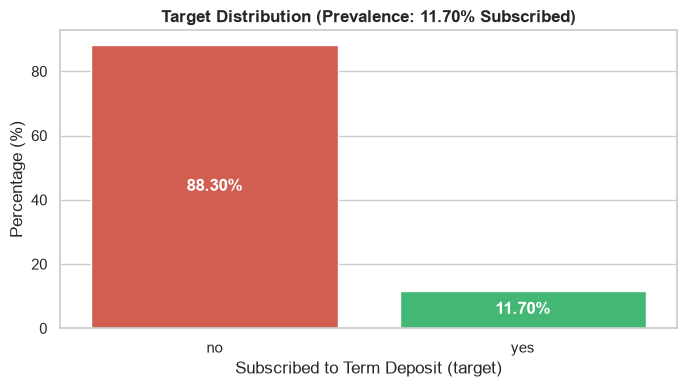

In [3]:
# Target prevalence
target_counts = df['target'].value_counts()
target_props = df['target'].value_counts(normalize=True)

print("Target Distribution:")
for k in target_counts.index:
    print(f"  '{k}': {target_counts[k]:,} ({target_props[k]*100:.2f}%)")

# Compute benchmarks at k=5,000
rand_bench = evaluate_random_baseline(df['target'], k=5000)
biz_bench = evaluate_business_rule_baseline(df, df['target'], k=5000)

print(f"\n1. Random Selection Benchmark @ 5,000: {rand_bench['conversions_at_k']:.0f} conversions (11.70% precision, 1.00x lift)")
print(f"2. Business-Rule Benchmark @ 5,000   : {biz_bench['conversions_at_k']:,} conversions (33.28% precision, 2.84x lift)")

# Plot target distribution
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=target_props.index, y=target_props.values * 100, hue=target_props.index, palette=["#e74c3c", "#2ecc71"], legend=False, ax=ax)
ax.set_title("Target Distribution (Prevalence: 11.70% Subscribed)", fontsize=12, fontweight="bold")
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Subscribed to Term Deposit (target)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


## 3. Leakage Protection Investigation: `duration`

> [!WARNING]
> **Pre-Call Pipeline Contract**: Call duration is strictly post-call information. An univariate model on `duration` alone scores an ROC-AUC of 0.8076. The supervised pre-call pipeline is leakage-protected by programmatically stripping `duration`. Any future unsupervised segmentation pipeline must adhere to this exact same pre-call feature contract.


Univariate ROC-AUC on 'duration' ALONE: 0.8076



Duration summary statistics (seconds) by target:
              mean         std  min    50%    75%     max
target                                                   
no      221.182806  207.383237  0.0  164.0  279.0  4918.0
yes     537.294574  392.525262  8.0  426.0  725.0  3881.0

Calls with duration = 0s: 3 (Conversion rate: 0.0%)


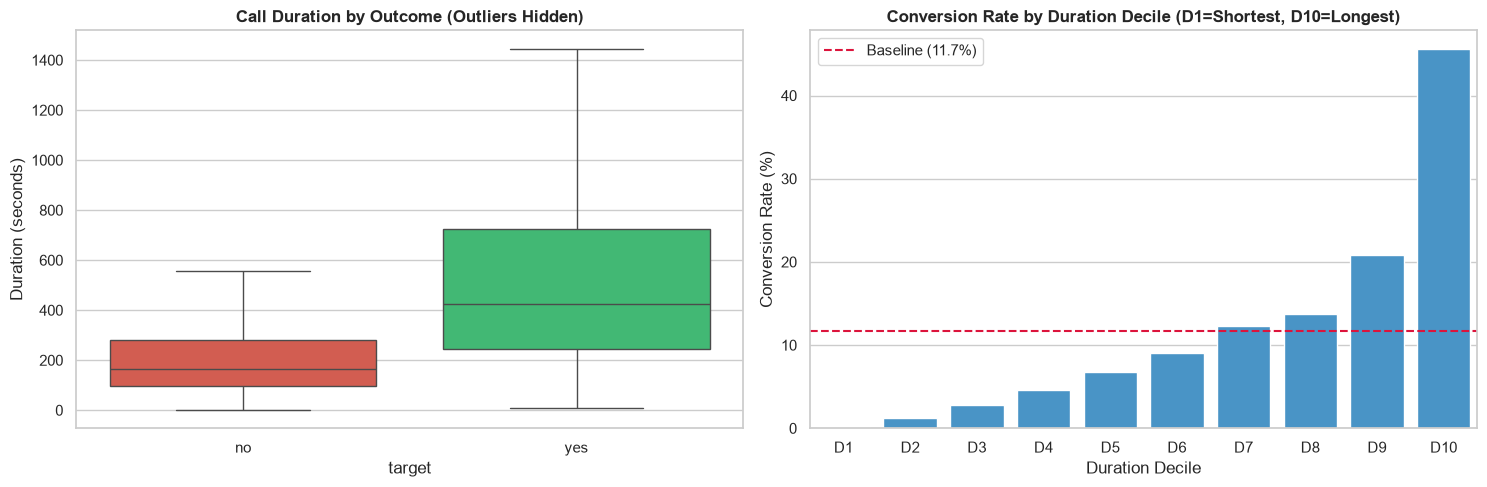

In [4]:
# 1. ROC-AUC of duration alone
y_binary = (df['target'] == 'yes').astype(int)
duration_auc = roc_auc_score(y_binary, df['duration'])
print(f"Univariate ROC-AUC on 'duration' ALONE: {duration_auc:.4f}")

# 2. Duration summary statistics by target
print("\nDuration summary statistics (seconds) by target:")
print(df.groupby('target')['duration'].describe()[['mean', 'std', 'min', '50%', '75%', 'max']])

# 3. Check duration = 0
zero_dur = df[df['duration'] == 0]
print(f"\nCalls with duration = 0s: {len(zero_dur)} (Conversion rate: {(zero_dur['target'] == 'yes').mean()*100:.1f}%)")

# 4. Visualization: Boxplot and Decile Conversion Rate
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot
sns.boxplot(data=df, x='target', y='duration', hue='target', showfliers=False, palette=["#e74c3c", "#2ecc71"], legend=False, ax=axes[0])
axes[0].set_title("Call Duration by Outcome (Outliers Hidden)", fontweight="bold")
axes[0].set_ylabel("Duration (seconds)")

# Deciles
df_temp = df[['duration', 'target']].copy()
df_temp['duration_decile'] = pd.qcut(df_temp['duration'], q=10)
decile_conv = df_temp.groupby('duration_decile', observed=False)['target'].agg(lambda s: (s == 'yes').mean() * 100).reset_index()
decile_conv['decile'] = [f"D{i+1}" for i in range(len(decile_conv))]

sns.barplot(data=decile_conv, x='decile', y='target', color='#3498db', ax=axes[1])
axes[1].axhline(y=11.70, color='crimson', linestyle='--', label='Baseline (11.7%)')
axes[1].set_title("Conversion Rate by Duration Decile (D1=Shortest, D10=Longest)", fontweight="bold")
axes[1].set_xlabel("Duration Decile")
axes[1].set_ylabel("Conversion Rate (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Campaign Outreach Dynamics (`campaign`)

### Observational Association:
Empirical conversion rates decline across higher contact frequency tiers. Rather than proving that calling someone causes them to decline, this observational pattern likely reflects a **negative selection effect**: interested prospects convert on early contacts (1–3), while recalcitrant prospects accumulate repeated contact records precisely because they have not subscribed. Raw counts are preserved in the pre-call pipeline without arbitrary clipping.


campaign_tier  record_count  conversions  conversion_rate  pct_of_all_records
    1 contact         17544         2561        14.597583           38.804716
   2 contacts         12505         1401        11.203519           27.659198
   3 contacts          5521          618        11.193624           12.211630
 4-5 contacts          5286          456         8.626561           11.691845
6-10 contacts          3159          206         6.521051            6.987238
 >10 contacts          1196           47         3.929766            2.645374


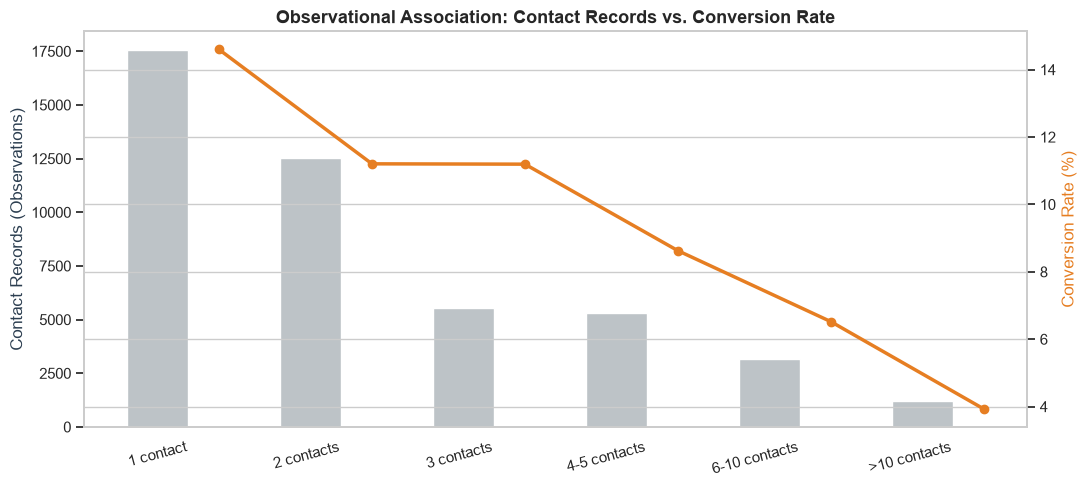

In [5]:
bins = [0, 1, 2, 3, 5, 10, 100]
labels = ["1 contact", "2 contacts", "3 contacts", "4-5 contacts", "6-10 contacts", ">10 contacts"]
df_camp = df[['campaign', 'target']].copy()
df_camp['campaign_tier'] = pd.cut(df_camp['campaign'], bins=bins, labels=labels)

camp_summary = df_camp.groupby('campaign_tier', observed=False)['target'].agg(
    record_count='count',
    conversions=lambda s: (s == 'yes').sum(),
    conversion_rate=lambda s: (s == 'yes').mean() * 100
).reset_index()
camp_summary['pct_of_all_records'] = camp_summary['record_count'] / len(df) * 100

print(camp_summary.to_string(index=False))

# Visualization: Contact Records vs Conversion Rate
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

x = np.arange(len(camp_summary))
width = 0.4
ax1.bar(x - width/2, camp_summary['record_count'], width=width, color='#bdc3c7', label='Contact Records')
ax2.plot(x + width/2, camp_summary['conversion_rate'], color='#e67e22', marker='o', linewidth=2.5, label='Conversion Rate (%)')

ax1.set_xticks(x)
ax1.set_xticklabels(camp_summary['campaign_tier'], rotation=15, ha='right')
ax1.set_ylabel('Contact Records (Observations)', color='#2c3e50')
ax2.set_ylabel('Conversion Rate (%)', color='#e67e22')
ax1.set_title("Observational Association: Contact Records vs. Conversion Rate", fontsize=13, fontweight='bold')
ax1.grid(False)

plt.tight_layout()
plt.show()


## 5. Prior Campaign History: `pdays`, `previous`, and `poutcome`

- `pdays = -1` indicates clients never previously contacted (**81.74%** of records, converting at **9.16%**).
- Prior contact (`pdays != -1`) converts at **23.07%** (2.5x higher).
- Prior success (`poutcome == 'success'`) converts at **64.73%** (5.5x higher than average).
- **Non-Absolute Relationship**: While missing `poutcome` predominantly corresponds to uncontacted clients (99.986%), exactly **5 records** have `pdays > 0` yet `poutcome` is `NaN` (repeat contacts with unrecorded prior CRM outcome).


--- Prior Contact Cohort Comparison ---
             contact_history  volume  conversions  conversion_rate
     Never Contacted (81.7%)   36954         3384         9.157331
Previously Contacted (18.3%)    8257         1905        23.071333

Exceptions where pdays != -1 but poutcome is NaN: 5 records
       pdays  previous poutcome target
40658     98         1      NaN    yes
41821    168         5      NaN     no
42042    188         2      NaN    yes
43978    416         2      NaN     no
45021    528         7      NaN     no

--- Prior Outcome (poutcome) Breakdown ---
prior_outcome  volume  conversions  conversion_rate
      failure    4901          618        12.609671
        other    1840          307        16.684783
      success    1511          978        64.725347
      unknown   36959         3386         9.161503


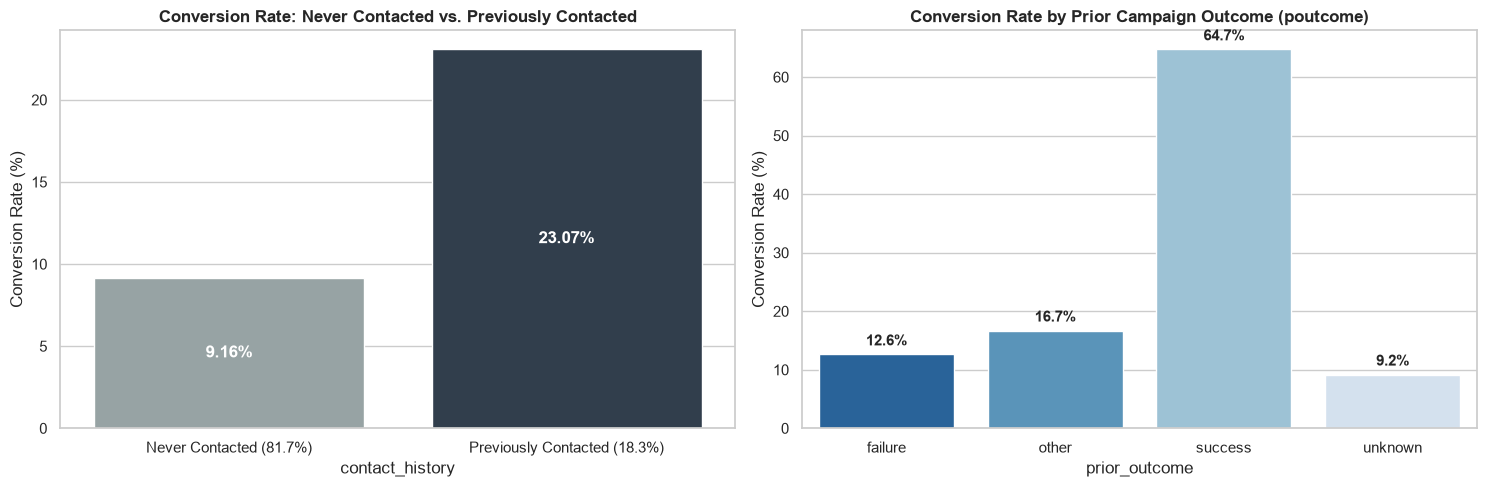

In [6]:
df_prior = df.copy()
df_prior['contact_history'] = np.where(df_prior['pdays'] == -1, 'Never Contacted (81.7%)', 'Previously Contacted (18.3%)')

pdays_stats = df_prior.groupby('contact_history')['target'].agg(
    volume='count',
    conversions=lambda s: (s == 'yes').sum(),
    conversion_rate=lambda s: (s == 'yes').mean() * 100
).reset_index()
print("--- Prior Contact Cohort Comparison ---")
print(pdays_stats.to_string(index=False))

# Identify the 5 exceptions
exceptions = df_prior[(df_prior['pdays'] != -1) & (df_prior['poutcome'].isna())]
print(f"\nExceptions where pdays != -1 but poutcome is NaN: {len(exceptions)} records")
print(exceptions[['pdays', 'previous', 'poutcome', 'target']])

pout_stats = df_prior.groupby(df_prior['poutcome'].fillna('unknown'))['target'].agg(
    volume='count',
    conversions=lambda s: (s == 'yes').sum(),
    conversion_rate=lambda s: (s == 'yes').mean() * 100
).reset_index().rename(columns={'poutcome': 'prior_outcome'})
print("\n--- Prior Outcome (poutcome) Breakdown ---")
print(pout_stats.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=pdays_stats, x='contact_history', y='conversion_rate', hue='contact_history', palette=['#95a5a6', '#2c3e50'], legend=False, ax=axes[0])
axes[0].set_title("Conversion Rate: Never Contacted vs. Previously Contacted", fontweight='bold')
axes[0].set_ylabel("Conversion Rate (%)")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                    ha='center', va='center', color='white', fontweight='bold', fontsize=12)

sns.barplot(data=pout_stats, x='prior_outcome', y='conversion_rate', hue='prior_outcome', palette='Blues_r', legend=False, ax=axes[1])
axes[1].set_title("Conversion Rate by Prior Campaign Outcome (poutcome)", fontweight='bold')
axes[1].set_ylabel("Conversion Rate (%)")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                    ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 6. Campaign Timing & Seasonality: Observational Trends

Analyzing contact records and observed conversion rates across calendar months. Differences reflect observational associations (differing cohort selections, promotional waves, and economic cycles) rather than causal effects.


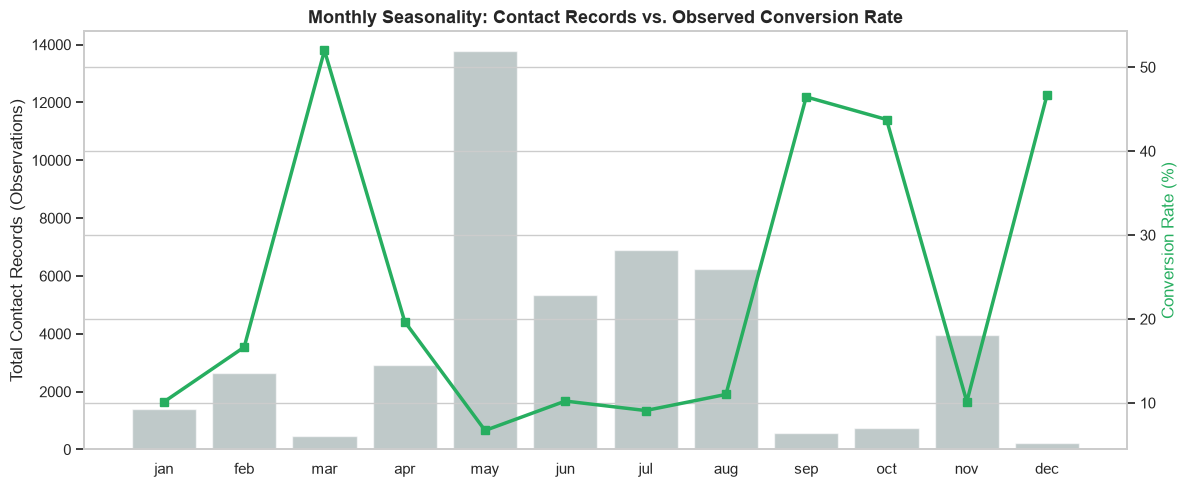

In [7]:
month_order = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
month_df = df.groupby('month')['target'].agg(
    record_count='count',
    conversions=lambda s: (s == 'yes').sum(),
    conversion_rate=lambda s: (s == 'yes').mean() * 100
).reindex(month_order).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(month_df['month'], month_df['record_count'], color='#95a5a6', alpha=0.6, label='Contact Records')
ax2.plot(month_df['month'], month_df['conversion_rate'], color='#27ae60', marker='s', linewidth=2.5, label='Conversion Rate (%)')

ax1.set_ylabel('Total Contact Records (Observations)')
ax2.set_ylabel('Conversion Rate (%)', color='#27ae60')
ax1.set_title("Monthly Seasonality: Contact Records vs. Observed Conversion Rate", fontsize=13, fontweight='bold')
ax1.grid(False)

plt.tight_layout()
plt.show()


## 7. Data Quality, Missingness & Repeated Demographic Profiles

- Missing values: Informative missingness in `poutcome` (81.7%) and `contact` (28.8%) is preserved via an explicit `unknown` category.
- Repeated demographic/financial profiles: 4,163 records (9.21%) share identical demographic/financial features. Due to the lack of unique customer IDs, these reflect profile overlaps across contact events rather than proven unique customer identities.


In [8]:
# Missing values
print("Missing (NaN) Counts:")
nan_counts = df.isna().sum()[lambda x: x > 0]
print(nan_counts)

# Repeated demographic profiles
demo_cols = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']
n_duplicates = df.duplicated(subset=demo_cols).sum()
print(f"\nRepeated demographic/financial profiles: {n_duplicates:,} out of {len(df):,} ({n_duplicates/len(df)*100:.2f}%)")
print("Validation Note: Stratified random splitting with validation-split model selection is employed.")


Missing (NaN) Counts:
job            288
education     1857
contact      13020
poutcome     36959
dtype: int64

Repeated demographic/financial profiles: 4,163 out of 45,211 (9.21%)
Validation Note: Stratified random splitting with validation-split model selection is employed.


## 8. Summary of Phase 1 Findings & Phase 2 Architecture

### Key Methodological Standards:
1. **Capacity Benchmarks**: Under the 5,000-call quota, Random Selection yields **585 conversions** (11.70%), while the Business-Rule Benchmark yields **1,664 conversions** (33.28%, 2.84x lift).
2. **Leakage Protection**: `duration` (ROC-AUC = 0.8076) is quarantined in the pre-call pipeline. The future unsupervised pipeline must adhere to this exact same pre-call feature contract.
3. **Validation Strategy**: Model selection is performed strictly on validation data using **Conversions@capacity** / **Precision@capacity** as the primary decision metric. The holdout test set is evaluated exactly once.
4. **Feature Normalization & Engineering**:
   - `day_of_week` (1-31) normalized to `contact_day_of_month`.
   - `was_previously_contacted`, non-negative `pdays_recency`, `has_debt_burden`, `negative_balance_flag`, signed `balance_log`.
   - Raw `campaign` counts preserved.
   - `unknown` preserved as an explicit categorical state for `poutcome` and `contact`.
